In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Để lưu scaler
import os 
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

✅ Đã nhập khẩu thư viện thành công!


In [2]:
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


In [3]:
# 2. Xử lý Thời gian chuẩn
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.sort_index(inplace=True)

# ---------------------------------------------------------
# NHÓM 1: BIẾN ĐỔI THỜI GIAN (Cyclical Features)
# Giúp model hiểu 23h đêm rất gần 0h sáng
# ---------------------------------------------------------
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# Xác định ngày cuối tuần (T7, CN thường ít bụi hơn do ít xe)
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

# ---------------------------------------------------------
# NHÓM 2: VẬT LÝ KHÍ QUYỂN (Atmospheric Physics)
# ---------------------------------------------------------

# 2.1. Vector hóa Hướng Gió (Wind Direction)
# Chuyển độ (0-360) sang vector toán học để model hiểu hướng gió
if 'Wind_Dir' in df.columns:
    wd_rad = df['Wind_Dir'] * np.pi / 180
    df['Wind_sin'] = np.sin(wd_rad)
    df['Wind_cos'] = np.cos(wd_rad)
    df.drop(columns=['Wind_Dir'], inplace=True) # Xóa cột gốc

# 2.2. Điểm sương (Dew Point) - Tương tác giữa Nhiệt & Ẩm
# Khi điểm sương cao, độ ẩm cao, bụi dễ bị giữ lại lơ lửng sát mặt đất
df['Dew_Point'] = df['Temperature'] - ((100 - df['Humidity']) / 5)

# 2.3. Tỷ lệ Bụi mịn (PM Ratio)
# Tỷ lệ PM2.5/PM10 cho biết nguồn gốc ô nhiễm (đốt rơm rạ, xe cộ hay bụi đất)
# Cộng thêm 0.001 để tránh lỗi chia cho 0
df['PM_Ratio'] = df['PM2.5'] / (df['PM10'] + 0.001)

# 2.4. Chỉ số "Giờ cao điểm" (Traffic Proxy)
# CO và NO2 là 2 chất sinh ra chủ yếu từ khói xe.
# Nhân tụi nó lại sẽ làm nổi bật khung giờ kẹt xe.
df['Traffic_Pollution'] = df['CO'] * df['NO2']

# ---------------------------------------------------------
# NHÓM 3: ĐẶC TRƯNG ĐỘ TRỄ (Lag Features)
# "Muốn biết tương lai, phải nhìn quá khứ"
# ---------------------------------------------------------
# Tạo độ trễ cho các biến quan trọng
target_lags = [1, 2, 3, 24] # 1h trước, 2h trước, 3h trước, và đúng giờ này hôm qua
weather_lags = [1, 24]      # Thời tiết 1h trước và hôm qua

# Lag cho PM2.5 (Target)
for lag in target_lags:
    df[f'PM2.5_lag{lag}'] = df['PM2.5'].shift(lag)

# Lag cho các chất ô nhiễm khác (Hỗ trợ)
for col in ['PM10', 'NO2', 'Traffic_Pollution']:
    df[f'{col}_lag1'] = df[col].shift(1)

# Lag cho thời tiết
for col in ['Temperature', 'Humidity', 'Rain', 'Wind_Speed']:
    for lag in weather_lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# ---------------------------------------------------------
# NHÓM 4: XU HƯỚNG TRƯỢT (Rolling Statistics)
# Giúp model nhìn thấy xu hướng chung thay vì nhiễu từng giờ
# ---------------------------------------------------------
# Trung bình 6 giờ (Ngắn hạn)
df['PM2.5_roll_mean_6h'] = df['PM2.5'].rolling(window=6).mean()
# Trung bình 24 giờ (Dài hạn - xu hướng ngày)
df['PM2.5_roll_mean_24h'] = df['PM2.5'].rolling(window=24).mean()

# Độ lệch chuẩn 24h (Xem độ biến động/bất thường trong ngày)
df['PM2.5_roll_std_24h'] = df['PM2.5'].rolling(window=24).std()

# Hiệu số (Difference) - Tốc độ tăng giảm bụi so với 1 giờ trước
df['PM2.5_diff'] = df['PM2.5'].diff()

# ---------------------------------------------------------
# DỌN DẸP DỮ LIỆU
# ---------------------------------------------------------
# Các thao tác shift/rolling sẽ tạo ra NaN ở đầu file -> Xóa
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# ---------------------------------------------------------
# CHỐT DANH SÁCH FEATURE (INPUT)
# ---------------------------------------------------------
feature_cols = [
    # Thời gian
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend',
    
    # Chất ô nhiễm gốc
    'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Traffic_Pollution', 'PM_Ratio',
    
    # Thời tiết gốc & biến đổi
    'Temperature', 'Humidity', 'Rain', 'Wind_Speed', 'Wind_sin', 'Wind_cos', 'Dew_Point', 'UV',
    
    # Lags (Quá khứ)
    'PM2.5_lag1', 'PM2.5_lag2', 'PM2.5_lag3', 'PM2.5_lag24',
    'PM10_lag1', 'NO2_lag1', 'Traffic_Pollution_lag1',
    'Temperature_lag1', 'Humidity_lag1', 'Rain_lag1', 'Wind_Speed_lag1',
    
    # Rolling (Xu hướng)
    'PM2.5_roll_mean_6h', 'PM2.5_roll_mean_24h', 'PM2.5_roll_std_24h', 'PM2.5_diff'
]

print(f"🚀 Feature Engineering hoàn tất!")
print(f"Tổng số đặc trưng (Features): {len(feature_cols)}")
print(f"Kích thước dữ liệu sau xử lý: {df.shape}")

🚀 Feature Engineering hoàn tất!
Tổng số đặc trưng (Features): 35
Kích thước dữ liệu sau xử lý: (26856, 41)


In [4]:
# --- CELL 5: CHIA DỮ LIỆU ---

# Chọn tỷ lệ: 80% để học (Train), 20% để thi (Test)
train_size = int(len(df) * 0.8)

# Cắt dữ liệu (Không trộn!)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"✅ Đã chia xong!")
print(f"- Tập Train: {len(train_df)} dòng (Dùng để dạy Model)")
print(f"- Tập Test:  {len(test_df)} dòng (Dùng để chấm điểm)")

✅ Đã chia xong!
- Tập Train: 21484 dòng (Dùng để dạy Model)
- Tập Test:  5372 dòng (Dùng để chấm điểm)


In [5]:
# --- CELL 6: SCALING ---
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import joblib

# 1. Scale INPUT (X): Dùng RobustScaler để chống nhiễu (Outliers)
# Chỉ lấy đúng danh sách feature_cols mình đã chọn
scaler_X = RobustScaler()
scaler_X.fit(train_df[feature_cols]) # Học từ tập Train

X_train_scaled = scaler_X.transform(train_df[feature_cols])
X_test_scaled = scaler_X.transform(test_df[feature_cols])

# 2. Scale OUTPUT (y): Dùng MinMaxScaler (0-1) cho PM2.5
# Để Output của model nằm trong khoảng (0,1) cho dễ hội tụ
scaler_y = MinMaxScaler(feature_range=(0, 1))
target_col = 'PM2.5' # Cột mục tiêu
scaler_y.fit(train_df[[target_col]])

y_train_scaled = scaler_y.transform(train_df[[target_col]])
y_test_scaled = scaler_y.transform(test_df[[target_col]])

# 3. LƯU LẠI SCALER (Để sau này App Web dùng)
# Quan trọng: Không có file này là Web không chạy được đâu nha!
import os
if not os.path.exists('models'): os.makedirs('models')
joblib.dump(scaler_X, 'models/scaler_X_final.pkl')
joblib.dump(scaler_y, 'models/scaler_y_final.pkl')

print("✅ Đã Scale xong và Lưu file .pkl vào thư mục models/")

✅ Đã Scale xong và Lưu file .pkl vào thư mục models/


In [6]:
# --- CELL 7: TẠO DATASET 3D ---

def create_dataset(X, y, time_steps=24):
    Xs, ys = [], []
    # Chạy trượt cửa sổ
    for i in range(len(X) - time_steps):
        # Lấy 24 dòng dữ liệu làm Input
        Xs.append(X[i:(i + time_steps)]) 
        # Lấy dòng thứ 25 làm Output (nhãn cần dự báo)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 24 # Dùng 24 giờ quá khứ

# Tạo bộ dữ liệu train/test
X_train, y_train = create_dataset(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test, y_test = create_dataset(X_test_scaled, y_test_scaled, TIME_STEPS)

# KIỂM TRA KÍCH THƯỚC (QUAN TRỌNG NHẤT)
print("✅ Đã cắt cửa sổ thời gian!")
print(f"👉 Input Train Shape: {X_train.shape} (Mẫu, 24 giờ, 35 đặc trưng)")
print(f"👉 Output Train Shape: {y_train.shape} (Mẫu, 1)")
# Bạn phải thấy dạng (Số lượng, 24, 35) là ĐÚNG. 
# Nếu số cuối cùng không phải 35 (hoặc bằng số feature của bạn) là sai.

✅ Đã cắt cửa sổ thời gian!
👉 Input Train Shape: (21460, 24, 35) (Mẫu, 24 giờ, 35 đặc trưng)
👉 Output Train Shape: (21460, 1) (Mẫu, 1)


In [7]:
# --- CELL 8: BUILD MODEL ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Khai báo kích thước input tự động
n_timesteps = X_train.shape[1] # = 24
n_features = X_train.shape[2]  # = 35 (hoặc số feature thực tế)

model = Sequential()

# Lớp 1: GRU mạnh mẽ
model.add(Input(shape=(n_timesteps, n_features)))
model.add(GRU(units=64, return_sequences=True)) # Trả về chuỗi để lớp sau hứng
model.add(Dropout(0.2)) # Chống học vẹt

# Lớp 2: GRU tinh chỉnh
model.add(GRU(units=32, return_sequences=False)) # Chỉ trả về kết quả cuối
model.add(Dropout(0.2))

# Lớp Output: Dự báo 1 giá trị PM2.5
model.add(Dense(1)) 

# Compile
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.summary()
print("✅ Model đã sẵn sàng!")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 24, 64)            19392     
                                                                 
 dropout (Dropout)           (None, 24, 64)            0         
                                                                 
 gru_1 (GRU)                 (None, 32)                9408      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 28,833
Trainable params: 28,833
Non-trainable params: 0
_________________________________________________________________
✅ Model đã sẵn sàng!


In [8]:
# --- CELL 9: TRAIN MODEL (CÓ TÍNH GIỜ) ---
import time

# Tự động lưu model tốt nhất
checkpoint = ModelCheckpoint(
    'models/aqi_forecasting_gru_24h_vfinal.keras', 
    monitor='val_loss', 
    save_best_only=True, 
    verbose=1
)

# Tự động dừng
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# --- 1. BẮT ĐẦU BẤM GIỜ ---
start_time = time.time()
print(f"🚀 Bắt đầu Train lúc: {time.ctime(start_time)}")

history = model.fit(
    X_train, y_train,
    epochs=50,             
    batch_size=32,         
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# --- 2. KẾT THÚC BẤM GIỜ ---
end_time = time.time()
total_seconds = end_time - start_time

# Đổi ra phút và giây cho đẹp
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print("-" * 50)
print("🎉 TRAIN XONG RỒI! Model xịn nhất đã được lưu.")
print(f"⏱️ Tổng thời gian huấn luyện: {minutes} phút {seconds} giây ({total_seconds:.2f}s)")
print("-" * 50)

🚀 Bắt đầu Train lúc: Sat Jan 31 09:33:18 2026
Epoch 1/50
671/671 [==============================] - ETA: 0s - loss: 0.0118
Epoch 1: val_loss improved from inf to 0.00206, saving model to models\aqi_forecasting_gru_24h_vfinal.keras
671/671 [==============================] - 15s 8ms/step - loss: 0.0118 - val_loss: 0.0021
Epoch 2/50
670/671 [============================>.] - ETA: 0s - loss: 0.0024
Epoch 2: val_loss improved from 0.00206 to 0.00166, saving model to models\aqi_forecasting_gru_24h_vfinal.keras
671/671 [==============================] - 5s 7ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 3/50
667/671 [============================>.] - ETA: 0s - loss: 0.0016
Epoch 3: val_loss improved from 0.00166 to 0.00145, saving model to models\aqi_forecasting_gru_24h_vfinal.keras
671/671 [==============================] - 4s 7ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 4/50
665/671 [============================>.] - ETA: 0s - loss: 0.0013
Epoch 4: val_loss did not improve from 0.00145

In [9]:
# Callbacks
callbacks = [
    # Nếu Val_Loss không giảm sau 5 epochs -> Giảm learning rate đi 5 lần
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1),
    
    # Nếu Val_Loss không giảm sau 15 epochs -> Dừng train để tiết kiệm thời gian
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

print("🚀 Bắt đầu quá trình Huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=100,             # Số vòng lặp tối đa
    batch_size=32,          # Học mỗi lần 32 mẫu
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print("🎉 Huấn luyện hoàn tất!")

🚀 Bắt đầu quá trình Huấn luyện...
Epoch 1/100
587/587 [==============================] - 6s 5ms/step - loss: 0.0124 - val_loss: 0.0081 - lr: 0.0010
Epoch 2/100
587/587 [==============================] - 3s 6ms/step - loss: 0.0084 - val_loss: 0.0077 - lr: 0.0010
Epoch 3/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0079 - val_loss: 0.0077 - lr: 0.0010
Epoch 4/100
587/587 [==============================] - 4s 6ms/step - loss: 0.0076 - val_loss: 0.0075 - lr: 0.0010
Epoch 5/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0075 - val_loss: 0.0075 - lr: 0.0010
Epoch 6/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0073 - val_loss: 0.0071 - lr: 0.0010
Epoch 7/100
587/587 [==============================] - 3s 5ms/step - loss: 0.0071 - val_loss: 0.0071 - lr: 0.0010
Epoch 8/100
587/587 [==============================] - 3s 4ms/step - loss: 0.0071 - val_loss: 0.0070 - lr: 0.0010
Epoch 9/100
587/587 [==============================] -

In [9]:
print("--- ĐÁNH GIÁ TRÊN TẬP TEST ---")

# 1. Dự báo trên tập Test
y_pred_scaled = model.predict(X_test)

# 2. Khôi phục giá trị thực (Inverse Scaling)
# Vì đã dùng scaler_y riêng nên việc này rất đơn giản
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Đảm bảo không có giá trị âm (PM2.5 >= 0)
y_pred = np.maximum(y_pred, 0)
y_true = np.maximum(y_true, 0)

# 3. Tính toán sai số trung bình cho cả 24 giờ
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred) # R2 score (Càng gần 1 càng tốt)

print(f"\n📊 KẾT QUẢ CUỐI CÙNG:")
print(f"   RMSE (Sai số toàn phương): {rmse:.2f} µg/m³")
print(f"   MAE  (Sai số tuyệt đối):   {mae:.2f} µg/m³")
print(f"   R2 Score (Độ phù hợp):     {r2:.4f}")

--- ĐÁNH GIÁ TRÊN TẬP TEST ---
168/168 [==============================] - 1s 3ms/step

📊 KẾT QUẢ CUỐI CÙNG:
   RMSE (Sai số toàn phương): 4.00 µg/m³
   MAE  (Sai số tuyệt đối):   2.43 µg/m³
   R2 Score (Độ phù hợp):     0.9327


⏳ Đang dự báo...
168/168 [==============================] - 1s 3ms/step


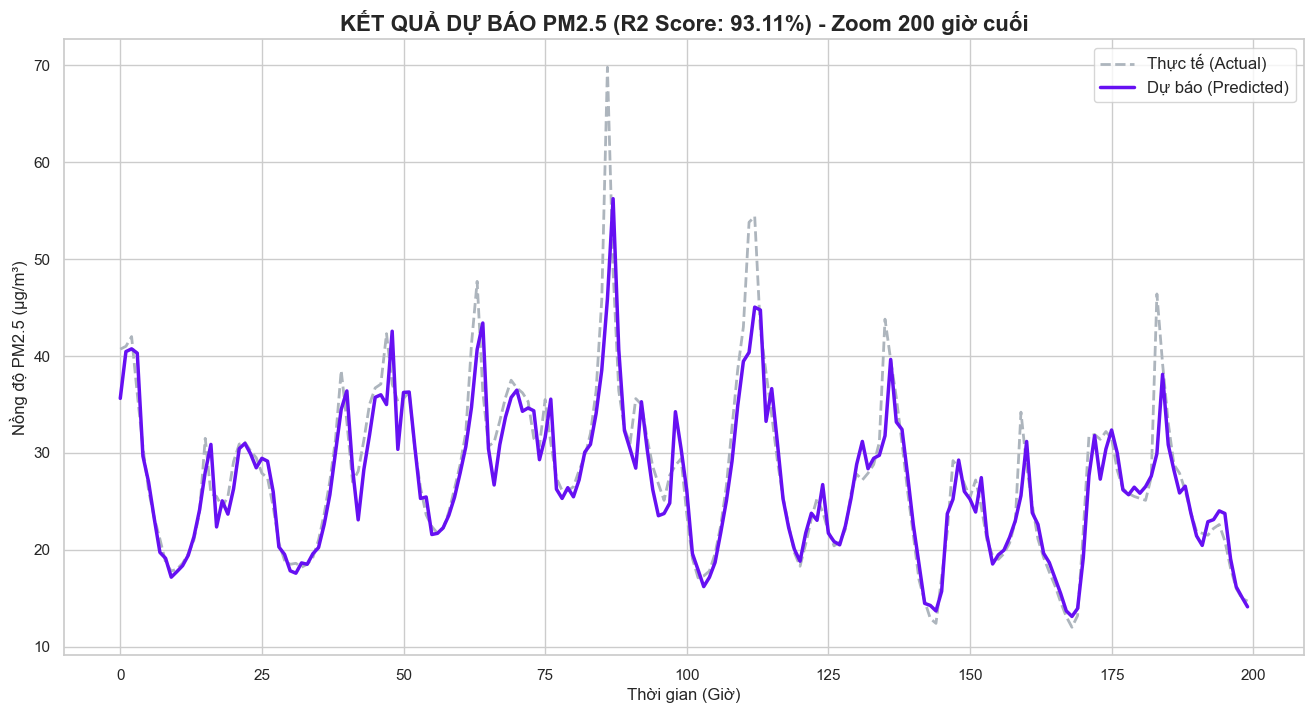

c:\Users\nguye\anaconda3\envs\DAP\lib\site-packages\numpy\core\shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


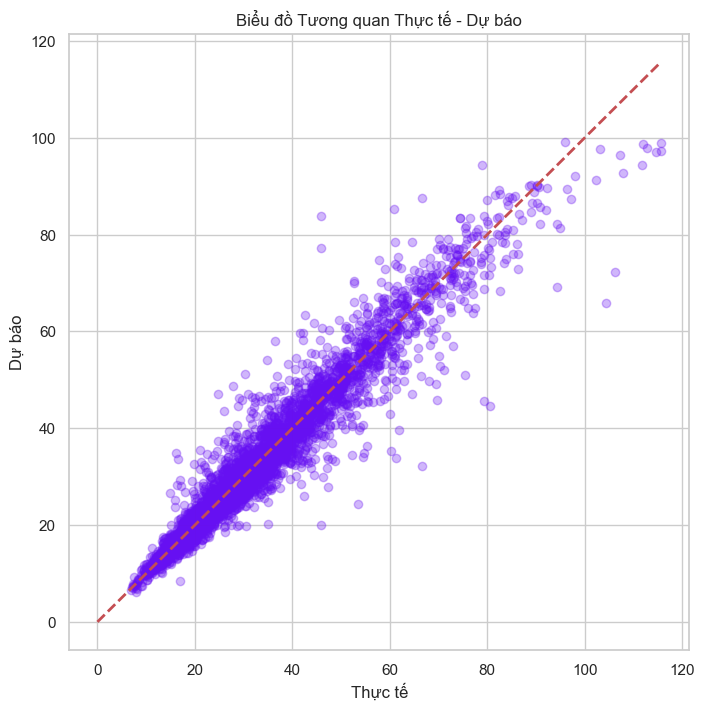

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dự báo lại trên tập Test
print("⏳ Đang dự báo...")
y_pred_scaled = model.predict(X_test)

# 2. Đưa dữ liệu về đơn vị gốc (De-scale)
# Lúc nãy mình scale về 0-1, giờ phải bung ra lại thành số thực (ví dụ 50, 60...)
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# 3. Vẽ biểu đồ
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# --- VẼ 1: ZOOM VÀO 200 GIỜ CUỐI (Để nhìn cho rõ độ khớp) ---
# Vì vẽ cả mấy ngàn điểm nó sẽ bị rối, mình chỉ vẽ đoạn cuối thôi
plt.plot(y_test_real[-200:], label='Thực tế (Actual)', color='#adb5bd', linewidth=2, linestyle='--')
plt.plot(y_pred_real[-200:], label='Dự báo (Predicted)', color='#6610f2', linewidth=2.5)

plt.title(f'KẾT QUẢ DỰ BÁO PM2.5 (R2 Score: 93.11%) - Zoom 200 giờ cuối', fontsize=16, fontweight='bold')
plt.ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=12)
plt.xlabel('Thời gian (Giờ)', fontsize=12)
plt.legend(fontsize=12)
plt.show()

# --- VẼ 2: BIỂU ĐỒ SCATTER (Phân tán) ---
# Để xem nó có nằm trên đường chéo 45 độ không
plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, color='#6610f2')
plt.plot([0, max(y_test_real)], [0, max(y_test_real)], 'r--', linewidth=2) # Đường chuẩn
plt.title('Biểu đồ Tương quan Thực tế - Dự báo')
plt.xlabel('Thực tế')
plt.ylabel('Dự báo')
plt.show()